# Results

In [1]:
from py_experimenter.experimenter import PyExperimenter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load Data

In [2]:
TABLE_NAME = "lcbench"
update_data = True

def get_data(table_name: str, update_data: bool) -> pd.DataFrame:
    cache_path = f"plain_data/{table_name}/table.csv"
    if update_data:
        experimenter = PyExperimenter(
            experiment_configuration_file_path="conf/experiment_config.yml",
            database_credential_file_path="conf/database_credentials.yml",
            table_name=table_name,
        )
        df = experimenter.get_table()
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        df.to_csv(cache_path, index=False)
    else:
        df = pd.read_csv(cache_path)
    return df

df = get_data(TABLE_NAME, update_data)
df = df[df["status"] == "done"]
df_lcbench = df[df["benchmark"] == "lcbench"]
df_synthetic = df[df["benchmark"] == "synthetic"]
print(f"{len(df_lcbench)} completed lcbench experiments")
print(f"{len(df_synthetic)} completed synthetic experiments")
df.head()

2026-04-14 18:48:20,351  | py-experimenter - INFO     | Found 14 keyfields
2026-04-14 18:48:20,353  | py-experimenter - INFO     | Found 6 resultfields
2026-04-14 18:48:20,354  | py-experimenter - INFO     | Found 2 logtables
2026-04-14 18:48:20,354  | py-experimenter - INFO     | Found logtable lcbench__sh_iterations
2026-04-14 18:48:20,354  | py-experimenter - INFO     | Found logtable lcbench__brackets
2026-04-14 18:48:20,354  | py-experimenter - WARNING  | No custom section defined in config
2026-04-14 18:48:20,354  | py-experimenter - WARNING  | No codecarbon section defined in config
2026-04-14 18:48:20,360  | py-experimenter - INFO     | Initialized and connected to database


3400 completed lcbench experiments
3400 completed synthetic experiments


,ID,run_id,optimizer,num_arms,benchmark,kernel,use_predicted_y,use_early_stopping,seed,dataset_id,...,name,machine,T_max,consumed_budget,remaining_arms,num_epsilon_optimal_arms,regret,epsilon_optimal,end_date,error
0,1,__AUTO__,successive_halving,256,lcbench,linear,0,0,0,0,...,PyExperimenter,cn1509,52,1152.0,1,16,0.0,1,2026-04-14 18:41:34,None
1,2,__AUTO__,hyperband,256,lcbench,linear,0,0,0,0,...,PyExperimenter,cn0668,52,1091.0,1,7,0.0,1,2026-04-14 18:45:30,None
2,3,__AUTO__,successive_halving,256,synthetic,linear,0,0,0,0,...,PyExperimenter,cn1506,256,1152.0,1,5,0.0,1,2026-04-14 18:41:28,None
3,4,__AUTO__,hyperband,256,synthetic,linear,0,0,0,0,...,PyExperimenter,cn1345,256,11310.0,1,10,0.0,1,2026-04-14 18:45:27,None
4,5,__AUTO__,successive_halving,256,lcbench,linear,0,1,0,0,...,PyExperimenter,cn1304,52,1152.0,2,16,0.0,1,2026-04-14 18:41:33,None


## Prepare Data

In [3]:
PRIOR_RENAME = {
    "uniform": "Uniform",
    "performance": "Performance",
    "rank": "Rank",
    "inverse_rank": "Inverse Rank",
    "indicator": "Indicator",
}

BASELINE_LABEL = "Baseline"

def prepare_data(df: pd.DataFrame, optimizer: str) -> pd.DataFrame:
    """Method variants (use_early_stopping=1) + baseline (uniform, no early stopping)."""
    method = df[(df["optimizer"] == optimizer) & (df["use_early_stopping"] == 1)].copy()
    baseline = df[
        (df["optimizer"] == optimizer)
        & (df["prior"] == "uniform")
        & (df["use_early_stopping"] == 0)
    ].copy()
    baseline["prior"] = BASELINE_LABEL
    combined = pd.concat([method, baseline], ignore_index=True)
    combined["prior"] = combined["prior"].map(PRIOR_RENAME).fillna(combined["prior"])
    return combined

## Plot

In [4]:
def pareto_plot(data: pd.DataFrame, title: str, xlim=None, ylim=None) -> plt.Figure:
    sns.set_theme(style="whitegrid", context="talk")

    ranked_priors = (
        data.groupby("prior")["consumed_budget"]
        .mean()
        .sort_values()
        .index.tolist()
    )
    # Put baseline last so it gets a distinct visual
    if BASELINE_LABEL in ranked_priors:
        ranked_priors = [p for p in ranked_priors if p != BASELINE_LABEL] + [BASELINE_LABEL]

    palette = sns.color_palette("tab10", n_colors=len(ranked_priors))
    markers = ["o", "s", "D", "^", "v", "P", "X", "*"]

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, prior in enumerate(ranked_priors):
        subset = data[data["prior"] == prior]
        m_reg = subset["regret"].mean()
        s_reg = subset["regret"].sem()
        m_bud = subset["consumed_budget"].mean()
        s_bud = subset["consumed_budget"].sem()

        is_baseline = prior == BASELINE_LABEL
        ax.errorbar(
            m_bud, m_reg,
            xerr=s_bud, yerr=s_reg,
            fmt=markers[i % len(markers)],
            label=prior,
            color=palette[i],
            markersize=9,
            capsize=3,
            markeredgewidth=2,
            alpha=0.6 if is_baseline else 0.9,
            linestyle="--" if is_baseline else "-",
        )

    ax.set_xlabel("Consumed Budget")
    ax.set_ylabel("Regret")
    ax.set_title(title)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=3,
        frameon=True,
    )
    plt.tight_layout()
    return fig

## LCBench

### Successive Halving

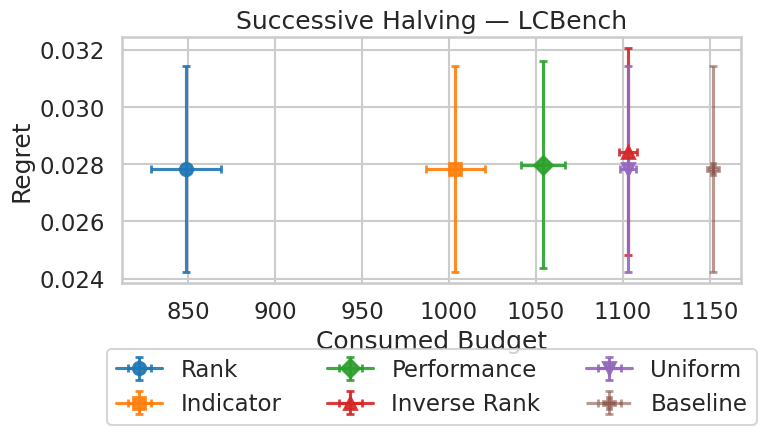

In [5]:
sh_lcbench = prepare_data(df_lcbench, "successive_halving")
fig = pareto_plot(sh_lcbench, "Successive Halving — LCBench")
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/sh_lcbench.pdf", bbox_inches="tight")
fig.savefig("plots/sh_lcbench.png", bbox_inches="tight", dpi=300)
plt.show()

### Hyperband

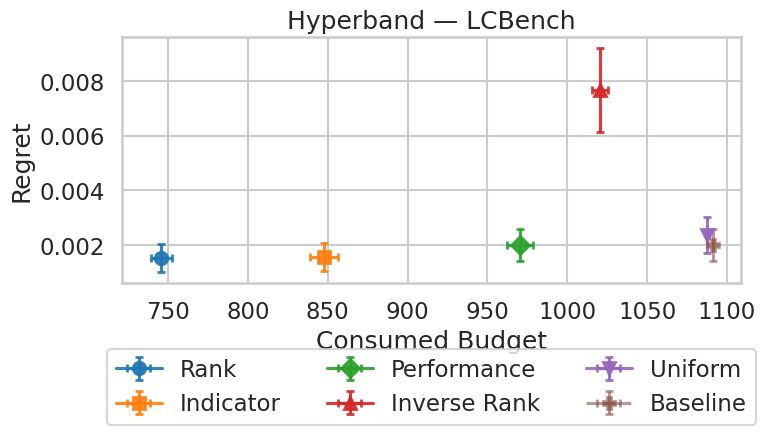

In [6]:
hb_lcbench = prepare_data(df_lcbench, "hyperband")
fig = pareto_plot(hb_lcbench, "Hyperband — LCBench")
fig.savefig("plots/hb_lcbench.pdf", bbox_inches="tight")
fig.savefig("plots/hb_lcbench.png", bbox_inches="tight", dpi=300)
plt.show()

## Synthetic

### Successive Halving

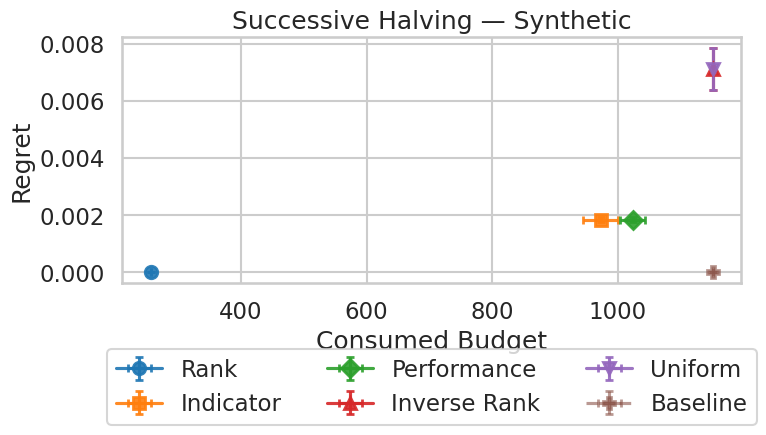

In [7]:
sh_synthetic = prepare_data(df_synthetic, "successive_halving")
fig = pareto_plot(sh_synthetic, "Successive Halving — Synthetic")
fig.savefig("plots/sh_synthetic.pdf", bbox_inches="tight")
fig.savefig("plots/sh_synthetic.png", bbox_inches="tight", dpi=300)
plt.show()

### Hyperband

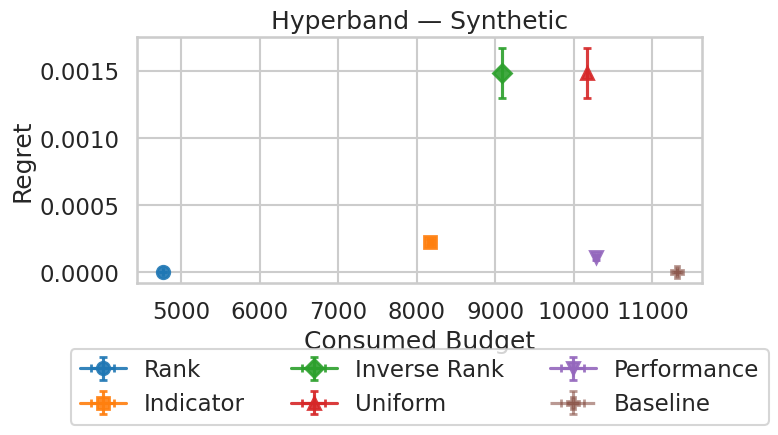

In [8]:
hb_synthetic = prepare_data(df_synthetic, "hyperband")
fig = pareto_plot(hb_synthetic, "Hyperband — Synthetic")
fig.savefig("plots/hb_synthetic.pdf", bbox_inches="tight")
fig.savefig("plots/hb_synthetic.png", bbox_inches="tight", dpi=300)
plt.show()